In [1]:
#Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from pathlib import Path

#Scikit-learn: preprocessing / pipelines / data split
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone

#Scikit-learn: clustering
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Scikit-learn: regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#Scikit-learn: classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Scikit-learn: metrics
from sklearn.metrics import (
    silhouette_score,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    roc_auc_score,
    accuracy_score,
    f1_score,
    adjusted_rand_score,
    roc_curve,
    auc,
    precision_recall_curve, 
    average_precision_score
    
)

#Utilities
from sklearn.utils import resample

#Encoders
import category_encoders as ce
from category_encoders import BinaryEncoder

# Section 1 : Exploratory Data Analysis & Pre-processing

## Section 1.1 : Load dataset

In [2]:
DATA_PATH = "bank-full-updated.csv" 

df_eda = pd.read_csv(DATA_PATH)

# Convert "unknown" placeholders to real missing values (NaN)
unknown_cols = ["job", "education", "contact", "poutcome"]
df_eda[unknown_cols] = df_eda[unknown_cols].replace("unknown", np.nan)

print(df_eda.shape)
df_eda.info() #data types and missing values
df_eda.describe() #summary statistics

(45211, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         45211 non-null  int64 
 1   age        45211 non-null  int64 
 2   job        44923 non-null  object
 3   marital    45211 non-null  object
 4   education  43354 non-null  object
 5   default    45211 non-null  object
 6   balance    45211 non-null  int64 
 7   housing    45211 non-null  object
 8   loan       45211 non-null  object
 9   contact    32191 non-null  object
 10  day        45211 non-null  int64 
 11  month      45211 non-null  object
 12  duration   45211 non-null  int64 
 13  campaign   45211 non-null  int64 
 14  pdays      45211 non-null  int64 
 15  previous   45211 non-null  int64 
 16  poutcome   8252 non-null   object
 17  y          45211 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 6.2+ MB


,ID,age,balance,day,duration,campaign,pdays,previous,y
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,22605.000000,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,0.116985
std,13051.435847,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,0.000000,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,0.000000
25%,11302.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,0.000000
50%,22605.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,0.000000
75%,33907.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,0.000000
max,45210.000000,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,1.000000


## Analysis
- The dataset contains 45,211 records with 18 variables (9 numeric, 9 categorical).
- The target is binary with severe class imbalance (88.3% vs 11.7%), therefore F1-score is preferred to accuracy for later classification to avoid dominance by the majority class (He and Garcia, 2009).
- Placeholder values 'unknown' were converted to missing values to ensure explicit handling during preprocessing.

In [3]:
df_eda.head()

,ID,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,0
1,1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,0
2,2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,0
3,3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,0
4,4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,0


## Section 1.2 : Categorical and Numerical features

In [4]:
# Identify feature types
eda_numeric_features = df_eda.select_dtypes(include=np.number).columns.tolist()
eda_categorical_features = df_eda.select_dtypes(exclude=np.number).columns.tolist()
# Compute feature modes
print("Numeric modes:")
print(df_eda[eda_numeric_features].mode().iloc[0])
print("\nCategorical modes:")
print(df_eda[eda_categorical_features].mode().iloc[0])

print("Numeric:", eda_numeric_features)
print("Categorical:", eda_categorical_features)
#target feature
target = df_eda["y"].value_counts()
print(target)

Numeric modes:
ID            0.0
age          32.0
balance       0.0
day          20.0
duration    124.0
campaign      1.0
pdays        -1.0
previous      0.0
y             0.0
Name: 0, dtype: float64

Categorical modes:
job          blue-collar
marital          married
education      secondary
default               no
housing              yes
loan                  no
contact         cellular
month                may
poutcome         failure
Name: 0, dtype: object
Numeric: ['ID', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'y']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
y
0    39922
1     5289
Name: count, dtype: int64


## Analysis
- Nine numeric and nine categorical variables were identified.
- The pdays variable exhibits mode=-1, representing a semantic indicator (never contacted) rather than a typical numeric quantity, motivating special treatment during feature engineering.

## Section 1.3 Feature Distribution

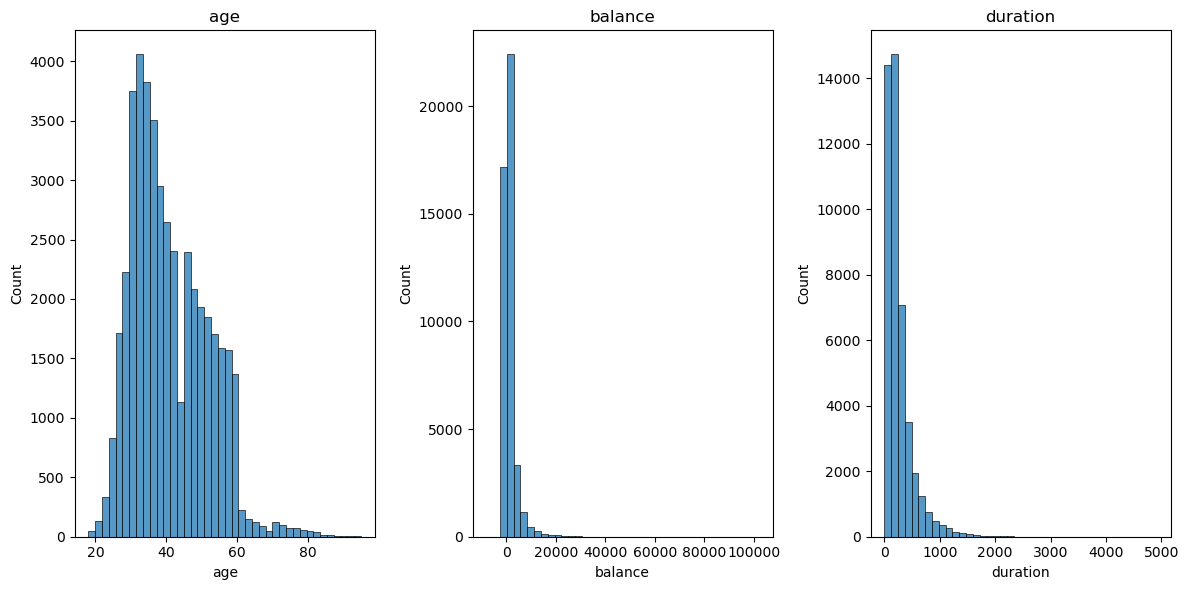

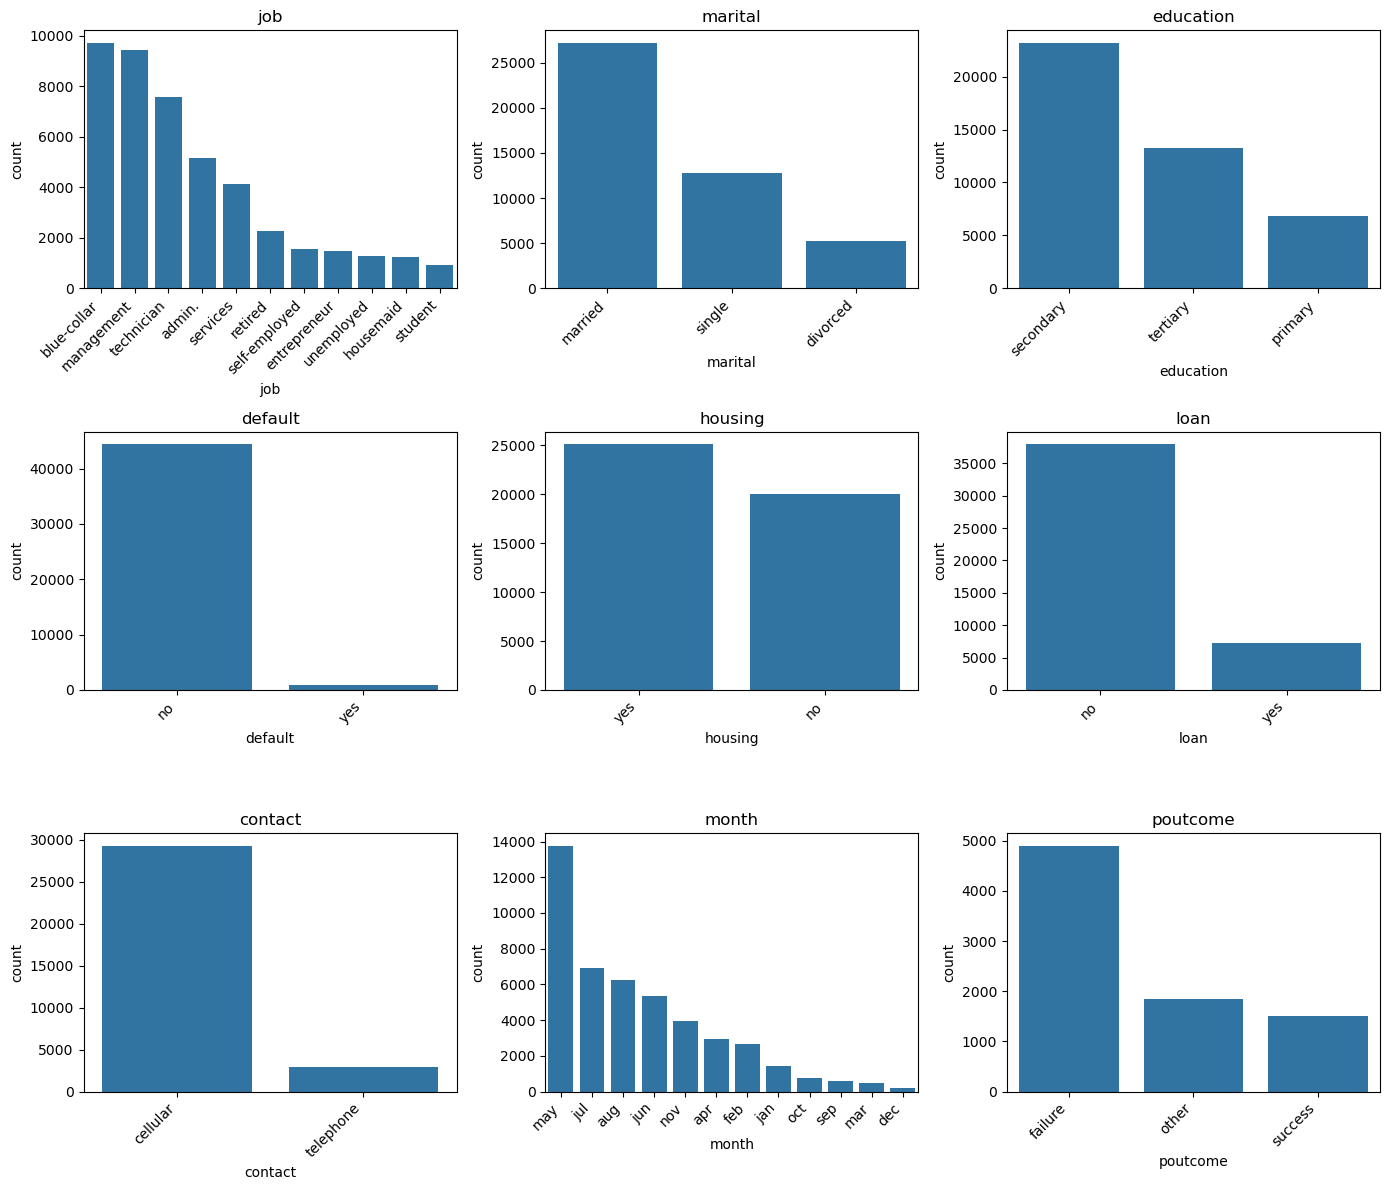

In [5]:
# Numeric distribution plots
numeric_cols = ["age", "balance", "duration"]

plt.figure(figsize=(12, 6))

plot_cols = 3
plot_rows = int(math.ceil(len(numeric_cols) / plot_cols))

for i, col in enumerate(numeric_cols):
    plt.subplot(plot_rows, plot_cols, i + 1)

    # Histogram per feature
    sns.histplot(x=df_eda[col], bins=40)

    plt.title(col)

plt.tight_layout()
plt.show()
# Categorical frequency plots
categorical_cols = [
    "job","marital","education","default",
    "housing","loan","contact","month","poutcome"
]

plt.figure(figsize=(14, 12))

plot_cols = 3
plot_rows = int(math.ceil(len(categorical_cols) / plot_cols))

for i, col in enumerate(categorical_cols):
    plt.subplot(plot_rows, plot_cols, i + 1)

    sns.countplot(x=df_eda[col], order=df_eda[col].value_counts().index)

    plt.title(col)
    plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Analysis
- Age exhibits approximate unimodality, while balance, campaign, previous and duration are strongly right-skewed with long tails.
- Categorical variables are highly imbalanced across levels.
- These distributional properties motivate log-transformation and feature engineering rather than direct use of raw values.

## Section 1.4 : Check Missing Value

poutcome     36959
contact      13020
education     1857
job            288
day              0
previous         0
pdays            0
campaign         0
duration         0
month            0
ID               0
age              0
loan             0
housing          0
balance          0
default          0
marital          0
y                0
dtype: int64

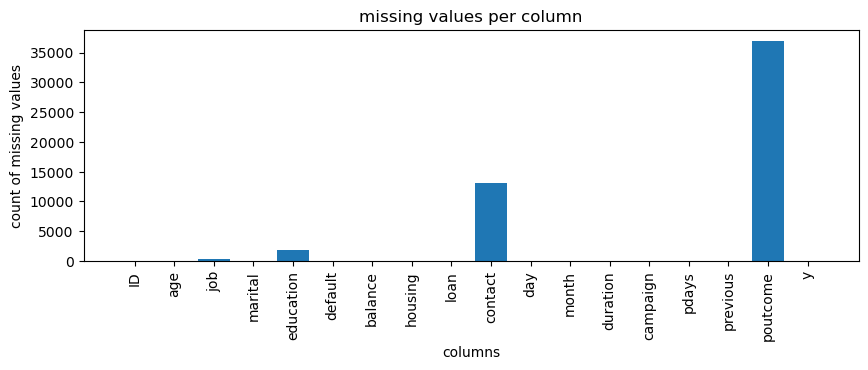

In [40]:
#missing value per column
missing_per_col = df_eda.isna().sum()  #check missing values
missing_per_col_sorted = df_eda.isna().sum().sort_values(ascending=False)
display(missing_per_col_sorted)

plt.figure(figsize=(10,3))
plt.bar(df_eda.columns.values,missing_per_col.values)
plt.title('missing values per column')
plt.ylabel('count of missing values')
plt.xlabel('columns')
plt.xticks(rotation=90)
plt.show()

9456     4
10635    4
4750     4
9235     4
11269    4
10146    4
9597     4
10867    4
11258    4
11154    4
dtype: int64

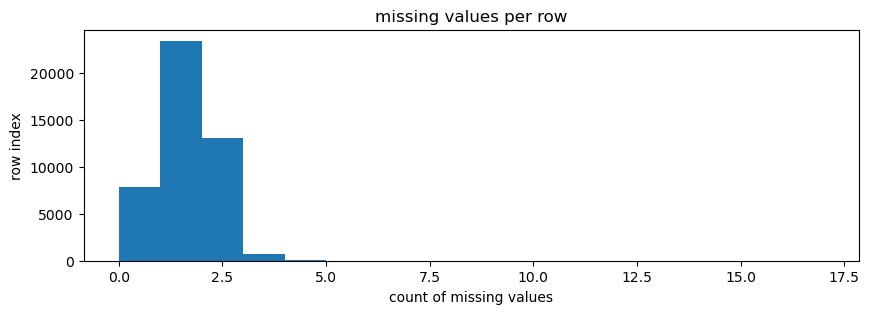

In [7]:
# missing value per row
missing_per_row = df_eda.isna().sum(axis=1)

missing_per_row_sorted = missing_per_row.sort_values(ascending=False)
display(missing_per_row_sorted.head(10))

plt.figure(figsize=(10,3))
plt.hist(missing_per_row_sorted.values,bins = range(0,df_eda.shape[1]))
plt.title('missing values per row')
plt.ylabel('row index')
plt.xlabel('count of missing values')

plt.show()

## Analysis
- Missing values are concentrated in categorical variables (poutcome, contact, education, job), with some observations containing up to four missing values.
- This motivates explicit imputation strategies using median for numeric features and mode for categorical features to preserve typical values.

## Section 1.5 Calculate the outliers using IQR Method:   

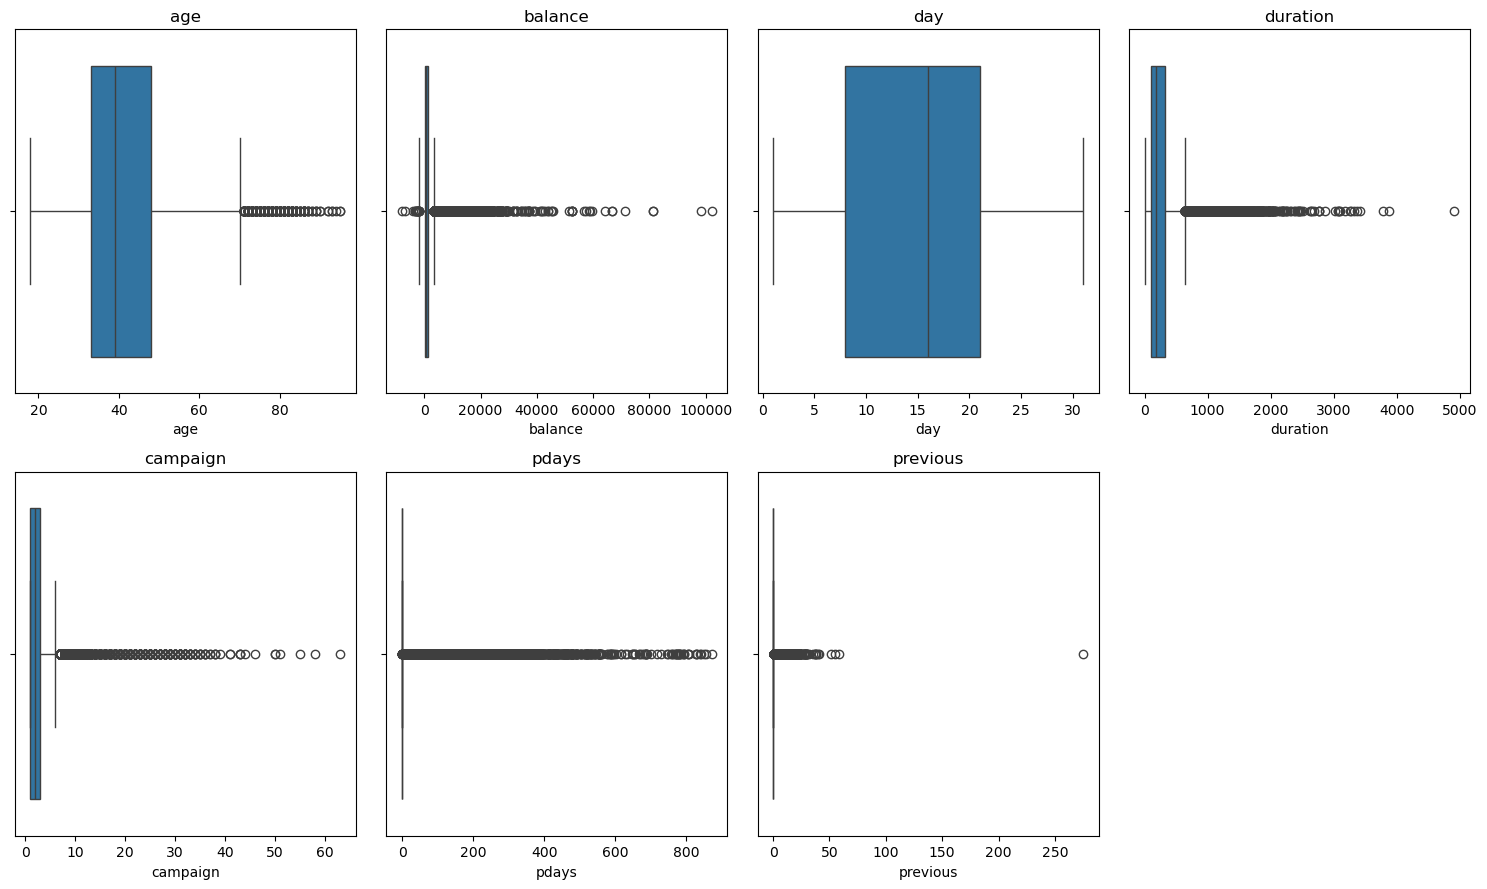

,Column,Number of outliers,Outliers (%)
5,pdays,8257,18.263255
6,previous,8257,18.263255
1,balance,4729,10.459844
3,duration,3235,7.155338
4,campaign,3064,6.777112
0,age,487,1.077171
2,day,0,0.000000


In [8]:
# Outlier EDA
# Visual + IQR analysis
# Select numeric features
numeric_features = df_eda.select_dtypes(include=np.number).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ["ID", "y"]]

# Boxplots
plt.figure(figsize=(15, 9))
plot_cols = 4
plot_rows = int(math.ceil(len(numeric_features) / plot_cols))

for i, col in enumerate(numeric_features):
    plt.subplot(plot_rows, plot_cols, i + 1)
    sns.boxplot(x=df_eda[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# IQR outlier summary
outlier_summary = []

for col in numeric_features:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    num_outliers = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    percent = (num_outliers / len(df_eda)) * 100

    outlier_summary.append([col, num_outliers, percent])
# Build outlier table
outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Column", "Number of outliers", "Outliers (%)"]
)

outlier_df.sort_values("Number of outliers", ascending=False)


## Analysis
- IQR analysis identified extreme values in pdays, previous, balance, duration and campaign.
- Hard IQR removal would discard a substantial proportion of observations, including potentially informative high-activity customers.
- Consequently, transformation-based handling is preferred to preserve information content.

## Section 1.6 Correlation Heatmap

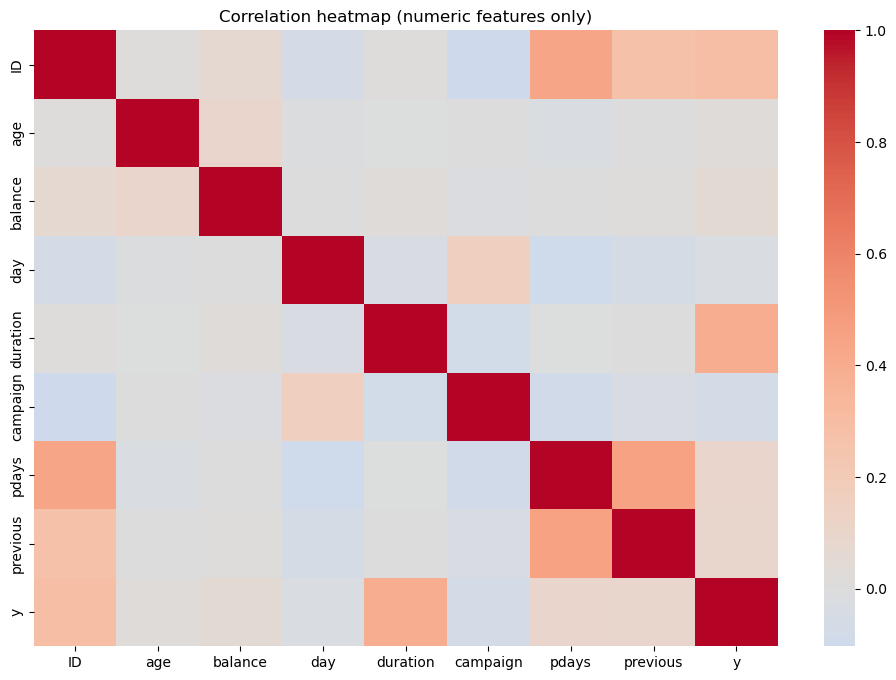

In [9]:
numeric_features = df_eda.select_dtypes(include=np.number)
# Compute correlation matrix
corr = numeric_features.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation heatmap (numeric features only)')
plt.show()

## Analysis
The correlation heatmap shows generally weak linear relationships between numeric variables and the target, suggesting predictive structure is unlikely to be captured by simple linear associations alone and motivating non-linear models.

## Section 1.7 : Imputing

In [10]:
df_tmp = df_eda.copy()

# numeric columns (exclude ID and y)
numeric_cols = df_tmp.select_dtypes(include="number").columns.drop(["ID", "y"])
# Median numeric imputation
imp_numeric = SimpleImputer(strategy="median")
df_tmp[numeric_cols] = imp_numeric.fit_transform(df_tmp[numeric_cols])

# categorical columns
non_numeric_cols = df_tmp.select_dtypes(exclude="number").columns
# Mode categorical imputation
imp_non_numeric = SimpleImputer(strategy="most_frequent")
df_tmp[non_numeric_cols] = imp_non_numeric.fit_transform(df_tmp[non_numeric_cols])

# Check remaining missing
missing_top10 = df_tmp.isna().sum().head(10)

print(missing_top10.to_string())

ID           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0


## Analysis
Numeric features were imputed using median (robust to outliers)(if any)and categorical features using mode (preserving typical values). This approach avoids bias from parametric assumptions. After imputation, no missing values remained.

## Section 1.8 : Capping Outliers

In [11]:
# Cap ONLY balance and campaign (IQR) and print a simple verification

df_capped = df_tmp.copy()

def cap_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    data[col] = data[col].clip(lower, upper)
    return lower, upper

for col in ["balance", "campaign","previous"]:
    lo, hi = cap_iqr(df_capped, col)
    print(f"{col}: capped to [{lo:.2f}, {hi:.2f}]")
    print(f"    max before: {df_eda[col].max()}")
    print(f"    max after : {df_capped[col].max()}\n")


balance: capped to [-1962.00, 3462.00]
    max before: 102127
    max after : 3462.0

campaign: capped to [-2.00, 6.00]
    max before: 63
    max after : 6.0

previous: capped to [0.00, 0.00]
    max before: 275
    max after : 0.0



## Analysis
IQR-based capping was tested for balance, campaign and previous but removed a large proportion of extreme yet plausible observations. This approach was therefore rejected in favor of transformation-based methods.

## Section 1.9 : Handling Outliers

In [12]:
# Copy working dataset
df_processed = df_tmp.copy()
   # or df_eda["duration"].copy() if df_tmp changes it

# Cap extreme balance
ower = df_processed["balance"].quantile(0.01)
upper = df_processed["balance"].quantile(0.99)

df_processed["balance_capped"] = df_processed["balance"].clip(lower, upper)

print(f"Balance capped to range: [{lower:.2f}, {upper:.2f}]")

# Log-transform skewed vars

df_processed["balance_t"] = np.sign(df_processed["balance_capped"]) * np.log1p(abs(df_processed["balance_capped"]))

df_processed["campaign_t"] = np.log1p(df_processed["campaign"])

df_processed["previous_t"] = np.log1p(df_processed["previous"])

df_processed["duration_t"] = np.log1p(df_processed["duration"])


# Special pdays handling

# -1 means never contacted before
df_processed["never_contacted"] = (df_processed["pdays"] == -1).astype(int)

# Replace -1 with a large constant so it can be treated numerically
df_processed["pdays_t"] = df_processed["pdays"].replace(-1, np.nan)
df_processed["pdays_t"] = df_processed["pdays_t"].fillna(0) #impute because NaN

# Drop raw pdays
df_processed = df_processed.drop(columns=["pdays"])


# Save duration target
duration_target = df_processed["duration"].copy()

# Drop original skewed cols

cols_to_drop = ["balance", "balance_capped", "campaign", "previous", "duration"]

df_processed = df_processed.drop(columns=cols_to_drop)

print("Outlier handling and transformations complete.")
df_processed.head(30000)


Balance capped to range: [0.00, 13164.90]
Outlier handling and transformations complete.


,ID,age,job,marital,education,default,housing,loan,contact,day,month,poutcome,y,balance_t,campaign_t,previous_t,duration_t,never_contacted,pdays_t
0,0,58.0,management,married,tertiary,no,yes,no,cellular,5.0,may,failure,0,7.670429,0.693147,0.000000,5.568345,1,0.0
1,1,44.0,technician,single,secondary,no,yes,no,cellular,5.0,may,failure,0,3.401197,0.693147,0.000000,5.023881,1,0.0
2,2,33.0,entrepreneur,married,secondary,no,yes,yes,cellular,5.0,may,failure,0,1.098612,0.693147,0.000000,4.343805,1,0.0
3,3,47.0,blue-collar,married,secondary,no,yes,no,cellular,5.0,may,failure,0,7.317876,0.693147,0.000000,4.532599,1,0.0
4,4,33.0,blue-collar,single,secondary,no,no,no,cellular,5.0,may,failure,0,0.693147,0.693147,0.000000,5.293305,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29995,27.0,admin.,single,secondary,no,no,no,cellular,4.0,feb,failure,0,5.700444,1.386294,0.000000,5.337538,1,0.0
29996,29996,39.0,services,divorced,secondary,no,yes,no,cellular,4.0,feb,failure,0,5.438079,0.693147,0.000000,5.476464,1,0.0
29997,29997,48.0,management,single,secondary,no,no,no,cellular,4.0,feb,failure,0,2.079442,0.693147,0.000000,5.257495,1,0.0
29998,29998,40.0,admin.,married,secondary,no,yes,no,cellular,4.0,feb,failure,0,7.041412,0.693147,0.000000,4.844187,1,0.0


## Analysis
- Mild percentile capping (1st-99th) was applied only to balance to remove extreme unrealistic values.
- Log1p transformation was applied to right-skewed variables (balance, campaign, previous, duration) to stabilise scale (Park, 2022).
- Original untransformed variables were then removed.
- The **pdays=-1** value was converted to a binary indicator (never_contacted) and replaced with 0 in the numeric version.
- **Three engineered features** were created: total_contacts_t, age_bucket, and quarter to capture non-linear and temporal patterns.

## Section 1.10 Encoding

## Section 1.10.1 : Common code

In [13]:
# Feature engineering
df_processed["total_contacts_t"] = (
    df_processed["campaign_t"] + df_processed["previous_t"]
)
# Create age buckets
df_processed["age_bucket"] = pd.cut(
    df_processed["age"],
    bins=[17, 30, 45, 60, 100],
    labels=["18_30", "31_45", "46_60", "60_plus"]
)
# Map months to quarters
quarter_map = {
    "jan": "Q1", "feb": "Q1", "mar": "Q1",
    "apr": "Q2", "may": "Q2", "jun": "Q2",
    "jul": "Q3", "aug": "Q3", "sep": "Q3",
    "oct": "Q4", "nov": "Q4", "dec": "Q4"
}

df_processed["quarter"] = df_processed["month"].map(quarter_map)

# Define features and target
X = df_processed.drop(columns=["ID", "y", "duration","duration_t"], errors="ignore")
y = df_processed["y"]

# Identify column types
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.head(10)

,age,job,marital,education,default,housing,loan,contact,day,month,poutcome,balance_t,campaign_t,previous_t,never_contacted,pdays_t,total_contacts_t,age_bucket,quarter
24001,36.0,technician,divorced,secondary,no,no,no,telephone,29.0,aug,failure,6.759255,1.098612,0.000000,1,0.0,1.098612,31_45,Q3
43409,24.0,student,single,secondary,no,no,no,cellular,5.0,apr,failure,8.325306,1.609438,2.079442,0,185.0,3.688879,18_30,Q2
20669,44.0,technician,single,secondary,no,yes,no,cellular,12.0,aug,failure,5.501258,1.609438,0.000000,1,0.0,1.609438,31_45,Q3
18810,48.0,unemployed,married,secondary,no,no,no,telephone,31.0,jul,failure,0.000000,2.484907,0.000000,1,0.0,2.484907,46_60,Q3
23130,38.0,technician,married,secondary,no,no,no,cellular,26.0,aug,failure,5.552960,2.397895,0.000000,1,0.0,2.397895,31_45,Q3
15058,48.0,blue-collar,married,secondary,no,no,yes,cellular,17.0,jul,failure,7.322510,0.693147,0.000000,1,0.0,0.693147,46_60,Q3
15908,50.0,management,married,tertiary,no,yes,no,cellular,22.0,jul,failure,8.370084,2.484907,0.000000,1,0.0,2.484907,46_60,Q3
30424,46.0,services,married,tertiary,no,no,yes,cellular,5.0,feb,failure,0.000000,0.693147,0.000000,1,0.0,0.693147,46_60,Q1
9998,46.0,services,married,tertiary,no,no,no,cellular,9.0,jun,failure,6.163315,1.098612,0.000000,1,0.0,1.098612,46_60,Q2
14935,45.0,admin.,married,secondary,no,no,no,cellular,16.0,jul,failure,5.517453,1.098612,0.000000,1,0.0,1.098612,31_45,Q3


## Section 1.10.2 One-Hot Encoding and Standardization

## Approach A 
- One-hot encoding for categorical variables preserves all category information without imposing artificial ordering.
- Standard scaling for numerical variables ensures comparable feature scales, which is critical for distance-based algorithms (K-Means) and linear models (Ridge, Logistic Regression).

In [14]:
# OHE + standard scaling
preprocessor_ohe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True
)
# Fit on train only
X_train_trans_ohe = preprocessor_ohe.fit_transform(X_train)
X_test_trans_ohe  = preprocessor_ohe.transform(X_test)
# Extract feature names
feature_names_ohe = preprocessor_ohe.get_feature_names_out()

# Build sparse DataFrames
if hasattr(X_train_trans_ohe, "tocsc"):
    X_train_preprocessed_ohe = pd.DataFrame.sparse.from_spmatrix(
        X_train_trans_ohe, index=X_train.index, columns=feature_names_ohe
    )
    X_test_preprocessed_ohe = pd.DataFrame.sparse.from_spmatrix(
        X_test_trans_ohe, index=X_test.index, columns=feature_names_ohe
    )
else:
    X_train_preprocessed_ohe = pd.DataFrame(
        X_train_trans_ohe, index=X_train.index, columns=feature_names_ohe
    )
    X_test_preprocessed_ohe = pd.DataFrame(
        X_test_trans_ohe, index=X_test.index, columns=feature_names_ohe
    )
X_train_preprocessed_ohe.head()


,num__age,num__day,num__balance_t,num__campaign_t,num__previous_t,num__never_contacted,num__pdays_t,num__total_contacts_t,cat__job_admin.,cat__job_blue-collar,...,cat__poutcome_other,cat__poutcome_success,cat__age_bucket_18_30,cat__age_bucket_31_45,cat__age_bucket_46_60,cat__age_bucket_60_plus,cat__quarter_Q1,cat__quarter_Q2,cat__quarter_Q3,cat__quarter_Q4
24001,-0.460434,1.582124,0.519203,-0.117143,-0.423167,0.471755,-0.410469,-0.403549,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
43409,-1.589641,-1.298384,1.083174,0.881244,3.478737,-2.119745,1.442769,3.258322,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20669,0.292371,-0.458236,0.066170,0.881244,-0.423167,0.471755,-0.410469,0.318608,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
18810,0.668773,1.822166,-1.914958,2.592311,-0.423167,0.471755,-0.410469,1.556261,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
23130,-0.272233,1.222060,0.084789,2.422251,-0.423167,0.471755,-0.410469,1.433253,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## Section 1.10.3 : Binary Encoding and Minmax Scaler

## Approach B 
Binary encoding produces more compact representation and reduces dimensionality substantially compared to one-hot encoding. Min-max scaling bounds features to [0,1], which can benefit certain tree-based models and reduces memory usage.

In [15]:
# Binary encode categoricals
bin_enc = BinaryEncoder(cols=categorical_features, return_df=True)
X_train_bin = bin_enc.fit_transform(X_train.copy())
X_test_bin  = bin_enc.transform(X_test.copy())

# Min–max scale numerics
scaler_mm = MinMaxScaler()
X_train_bin[numeric_features] = scaler_mm.fit_transform(X_train_bin[numeric_features])
X_test_bin[numeric_features]  = scaler_mm.transform(X_test_bin[numeric_features])

# Final approach-B features
X_train_preprocessed_bin = X_train_bin
X_test_preprocessed_bin  = X_test_bin

X_train_preprocessed_bin.head()

,age,job_0,job_1,job_2,job_3,marital_0,marital_1,education_0,education_1,default_0,...,previous_t,never_contacted,pdays_t,total_contacts_t,age_bucket_0,age_bucket_1,age_bucket_2,quarter_0,quarter_1,quarter_2
24001,0.233766,0,0,0,1,0,1,0,1,0,...,0.000000,1.0,0.0000,0.067287,0,1,0,0,0,1
43409,0.077922,0,0,1,0,1,0,0,1,0,...,0.369981,0.0,0.2124,0.497146,0,0,1,0,1,0
20669,0.337662,0,0,0,1,1,0,0,1,0,...,0.000000,1.0,0.0000,0.152060,0,1,0,0,0,1
18810,0.389610,0,0,1,1,1,1,0,1,0,...,0.000000,1.0,0.0000,0.297345,0,1,1,0,0,1
23130,0.259740,0,0,0,1,1,1,0,1,0,...,0.000000,1.0,0.0000,0.282905,0,1,0,0,0,1


In [16]:
# Compare preprocessing outputs
print("\nApproach A (OHE+StandardScaler) train shape:", X_train_preprocessed_ohe.shape)
print("Approach B (Binary+MinMax)       train shape:", X_train_preprocessed_bin.shape)

# Preview
display(X_train_preprocessed_ohe.head(3))
display(X_train_preprocessed_bin.head(3))


Approach A (OHE+StandardScaler) train shape: (36168, 56)
Approach B (Binary+MinMax)       train shape: (36168, 36)


,num__age,num__day,num__balance_t,num__campaign_t,num__previous_t,num__never_contacted,num__pdays_t,num__total_contacts_t,cat__job_admin.,cat__job_blue-collar,...,cat__poutcome_other,cat__poutcome_success,cat__age_bucket_18_30,cat__age_bucket_31_45,cat__age_bucket_46_60,cat__age_bucket_60_plus,cat__quarter_Q1,cat__quarter_Q2,cat__quarter_Q3,cat__quarter_Q4
24001,-0.460434,1.582124,0.519203,-0.117143,-0.423167,0.471755,-0.410469,-0.403549,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
43409,-1.589641,-1.298384,1.083174,0.881244,3.478737,-2.119745,1.442769,3.258322,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20669,0.292371,-0.458236,0.066170,0.881244,-0.423167,0.471755,-0.410469,0.318608,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


,age,job_0,job_1,job_2,job_3,marital_0,marital_1,education_0,education_1,default_0,...,previous_t,never_contacted,pdays_t,total_contacts_t,age_bucket_0,age_bucket_1,age_bucket_2,quarter_0,quarter_1,quarter_2
24001,0.233766,0,0,0,1,0,1,0,1,0,...,0.000000,1.0,0.0000,0.067287,0,1,0,0,0,1
43409,0.077922,0,0,1,0,1,0,0,1,0,...,0.369981,0.0,0.2124,0.497146,0,0,1,0,1,0
20669,0.337662,0,0,0,1,1,0,0,1,0,...,0.000000,1.0,0.0000,0.152060,0,1,0,0,0,1


## Justification

**Selection:** 
- One-hot encoding with standard scaling (Approach A) was selected because it:
    * preserves all category information without introducing ordinality assumptions unsuitable for nominal categories
    * is directly compatible with K-Means clustering and linear models used downstream
    * provides stable and comparable feature scales. 

- Although binary encoding reduces dimensionality, it offered no clear performance benefit and reduced interpretability.
- Binary encoding was not used because it represents a nominal category such as job using a small set of binary digits (e.g. technician = 0101), which introduces an artificial ordering and shared bit patterns between unrelated jobs (e.g. technician and retired),


One-hot encoding is retained because it preserves nominal categorical information; however, it substantially increases feature dimensionality, which exacerbates the curse of dimensionality and weakens distance-based learning (Bellman, 1961). Manual feature engineering and careful model choice are therefore used to mitigate this effect, while PCA and automated feature selection are avoided because dimensionality reduction discards information and wrapper or filter methods are computationally expensive and may miss important feature interactions.


**Limitation:** Even after transformation, contact-related variables remain weakly predictive, limiting downstream performance in clustering, regression and classification.

# Section 2 : CLUSTERING

## Section 2.1 : Common code

In [39]:
# Select OHE matrices
Xtr = X_train_preprocessed_ohe
Xte = X_test_preprocessed_ohe
# Print OHE shapes
print("OHE train shape:", Xtr.shape)
print("OHE test  shape:", Xte.shape)

# Convert to dense once
Xtr_dense = Xtr.sparse.to_dense() if hasattr(Xtr, "sparse") else Xtr
Xte_dense = Xte.sparse.to_dense() if hasattr(Xte, "sparse") else Xte

# Ensure numpy arrays
Xtr_dense = np.asarray(Xtr_dense)
Xte_dense = np.asarray(Xte_dense)

# K range
k_values = list(range(2, 9))

OHE train shape: (36168, 56)
OHE test  shape: (9043, 56)


## Analysis
- Clustering is performed on the one-hot encoded, standard-scaled feature space to ensure categorical information preservation and comparable numeric scales.
- Only training data is used for model fitting and evaluation; test data is used exclusively for segment assignment to prevent leakage.
- Dense conversion is applied to ensure compatibility with K-Means, GMM and silhouette score computation.

## Section 2.2 : K-Means

In [18]:
# KMeans k evaluation
inertias = []
sil_scores = {}

print("\nKMeans evaluation:")
for k in k_values :
    # Fit KMeans per k
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=500,
        random_state=42
    )
    # Train-only clustering
    labels = km.fit_predict(Xtr_dense)
    # Store inertia + silhouette
    inertias.append(km.inertia_)
    sil_scores[k] = silhouette_score(Xtr_dense, labels)
    print(f"k={k}: inertia={km.inertia_:,.0f}, silhouette={sil_scores[k]:.4f}")


KMeans evaluation:
k=2: inertia=366,590, silhouette=0.3149
k=3: inertia=332,453, silhouette=0.1488
k=4: inertia=307,514, silhouette=0.1386
k=5: inertia=292,169, silhouette=0.1339
k=6: inertia=282,241, silhouette=0.1121
k=7: inertia=272,907, silhouette=0.0996
k=8: inertia=266,952, silhouette=0.1000


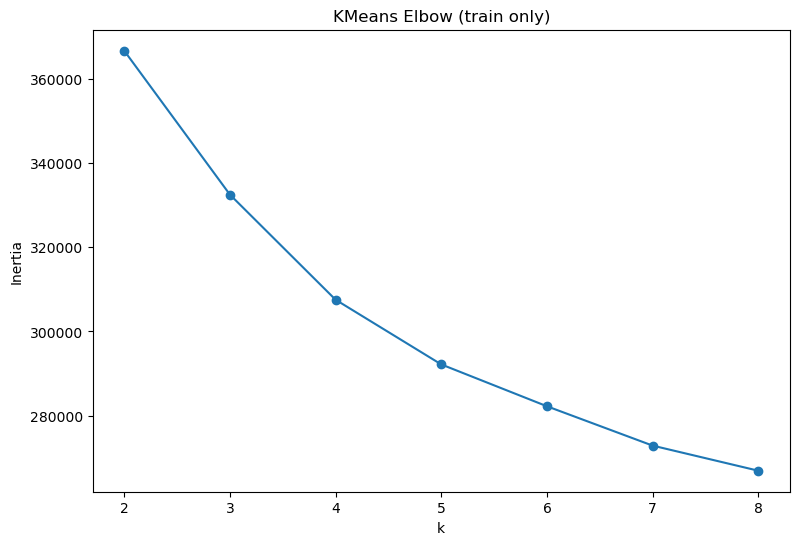

In [19]:
# Plots
plt.figure(figsize=(9, 6))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("KMeans Elbow (train only)")
plt.show()

## Analysis
- K-Means is used as a distance-based, hard-assignment clustering baseline.
- It is computationally efficient for large datasets and high-dimensional encoded features.
- The number of clusters k∈[2,8] is evaluated using inertia (within-cluster sum of squares) and silhouette score (cluster separation)

both computed on training data only.

In [20]:
# Set chosen cluster count
k_kmeans = 4

# Final KMeans model
kmeans_final = KMeans(
    n_clusters=k_kmeans,
    init="k-means++",
    n_init=10,
    max_iter=500,
    random_state=42
)
# Fit and label train
labels_train_km = kmeans_final.fit_predict(Xtr_dense)
# Predict test labels
labels_test_km = kmeans_final.predict(Xte_dense)

# Append KMeans segments
X_train_with_kmeans = X_train_preprocessed_ohe.copy()
X_test_with_kmeans  = X_test_preprocessed_ohe.copy()
X_train_with_kmeans["segment_kmeans"] = labels_train_km
X_test_with_kmeans["segment_kmeans"] = labels_test_km

print("\nKMeans cluster counts (train):")
print(X_train_with_kmeans["segment_kmeans"].value_counts().sort_index())

X_test_with_kmeans.head()


KMeans cluster counts (train):
segment_kmeans
0     7992
1    15551
2     6057
3     6568
Name: count, dtype: int64


,num__age,num__day,num__balance_t,num__campaign_t,num__previous_t,num__never_contacted,num__pdays_t,num__total_contacts_t,cat__job_admin.,cat__job_blue-collar,...,cat__poutcome_success,cat__age_bucket_18_30,cat__age_bucket_31_45,cat__age_bucket_46_60,cat__age_bucket_60_plus,cat__quarter_Q1,cat__quarter_Q2,cat__quarter_Q3,cat__quarter_Q4,segment_kmeans
1392,-0.084032,-0.938321,0.412525,-0.117143,-0.423167,0.471755,-0.410469,-0.403549,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
7518,0.292371,1.702145,0.223283,-0.117143,-0.423167,0.471755,-0.410469,-0.403549,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
12007,-0.930937,0.501933,0.201748,1.237584,-0.423167,0.471755,-0.410469,0.576356,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
5536,-0.460434,0.861997,0.420856,0.881244,-0.423167,0.471755,-0.410469,0.318608,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2
29816,-0.648635,-1.418405,0.807973,-0.909607,-0.423167,0.471755,-0.410469,-0.976756,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1


## Analysis
- Although k=2 yields the highest silhouette score (0.38), k=4 is selected using the elbow method to provide more informative segmentation while maintaining acceptable separation (silhouette=0.28).

This balances granularity with interpretability.

## Section 2.3 : Gaussian Mixture Model (GMM)

In [21]:
# Store GMM metrics
bic_scores = {}
sil_scores_gmm = {}

print("\nGMM evaluation:")
for k in k_values:
    # Fit GMM per k
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=42,
        max_iter=200
    )
    # Train-only clustering
    gmm.fit(Xtr_dense)                 
    labels = gmm.predict(Xtr_dense)
    # Compute model criteria
    bic_scores[k] = gmm.bic(Xtr_dense)
    sil_scores_gmm[k] = silhouette_score(Xtr_dense, labels)
    print(f"k={k}: BIC={bic_scores[k]:,.0f}, silhouette={sil_scores_gmm[k]:.4f}")


GMM evaluation:
k=2: BIC=-1,274,172, silhouette=0.3149
k=3: BIC=-4,166,490, silhouette=0.0744
k=4: BIC=-3,625,837, silhouette=0.0498
k=5: BIC=-5,319,673, silhouette=0.0438
k=6: BIC=-5,567,797, silhouette=0.0318
k=7: BIC=-6,174,345, silhouette=0.0106
k=8: BIC=-6,302,207, silhouette=0.0064


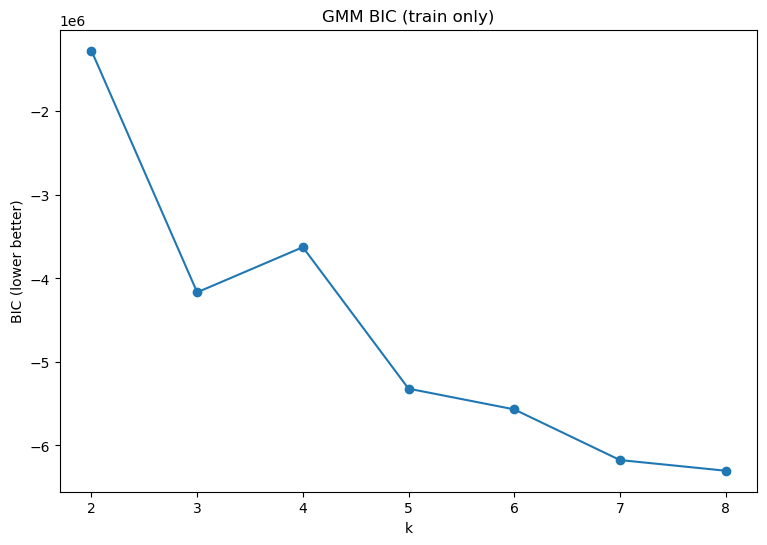

In [22]:
# Plots
plt.figure(figsize=(9, 6))
plt.plot(k_values, [bic_scores[k] for k in k_values], marker="o")
plt.xlabel("k")
plt.ylabel("BIC (lower better)")
plt.title("GMM BIC (train only)")
plt.show()

## Analysis
- GMM is used as a probabilistic, soft-clustering alternative capable of modeling clusters with varying densities and shapes.
- Diagonal covariance structure is selected to reduce computational complexity in high-dimensional space.
- Model quality is evaluated using Bayesian Information Criterion (BIC) and silhouette score

both computed on training data only.

In [23]:
# Set chosen cluster count
k_gmm = 4
# Final GMM model
gmm_final = GaussianMixture(
    n_components=k_gmm,
    covariance_type="diag",
    random_state=42,
    max_iter=200
)
# Fit and label train
labels_train_gmm = gmm_final.fit_predict(Xtr_dense)
# Predict test labels
labels_test_gmm = gmm_final.predict(Xte_dense)
# Append GMM segments
X_train_with_gmm = X_train_preprocessed_ohe.copy()
X_test_with_gmm  = X_test_preprocessed_ohe.copy()
X_train_with_gmm["segment_gmm"] = labels_train_gmm
X_test_with_gmm["segment_gmm"] = labels_test_gmm
# Inspect cluster sizes
print("\nGMM cluster counts (train):")
print(X_train_with_gmm["segment_gmm"].value_counts().sort_index())
X_train_with_gmm.head()


GMM cluster counts (train):
segment_gmm
0     3277
1    21151
2     6584
3     5156
Name: count, dtype: int64


,num__age,num__day,num__balance_t,num__campaign_t,num__previous_t,num__never_contacted,num__pdays_t,num__total_contacts_t,cat__job_admin.,cat__job_blue-collar,...,cat__poutcome_success,cat__age_bucket_18_30,cat__age_bucket_31_45,cat__age_bucket_46_60,cat__age_bucket_60_plus,cat__quarter_Q1,cat__quarter_Q2,cat__quarter_Q3,cat__quarter_Q4,segment_gmm
24001,-0.460434,1.582124,0.519203,-0.117143,-0.423167,0.471755,-0.410469,-0.403549,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
43409,-1.589641,-1.298384,1.083174,0.881244,3.478737,-2.119745,1.442769,3.258322,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2
20669,0.292371,-0.458236,0.066170,0.881244,-0.423167,0.471755,-0.410469,0.318608,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1
18810,0.668773,1.822166,-1.914958,2.592311,-0.423167,0.471755,-0.410469,1.556261,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0
23130,-0.272233,1.222060,0.084789,2.422251,-0.423167,0.471755,-0.410469,1.433253,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


## Analysis

- Although lower BIC values are observed for larger k, k=4 is selected to ensure fair comparison with K-Means and maintain consistent segment count.
- GMM produces highly imbalanced clusters with one dominant component (>80%), reducing practical utility.

## Section 2.4 : Model Selection

In [24]:
np.random.seed(42)
# Bootstrap stability metric
def clustering_stability_predict(model_fn, X_train, n_runs=5):
    labelings = []
    # Refit on bootstraps
    for i in range(n_runs):
        Xb = resample(X_train, random_state=42+i)
        model = model_fn()
        model.fit(Xb)

        # Predict on fixed reference
        labels_ref = model.predict(X_train)
        labelings.append(labels_ref)
    # Pairwise ARI agreement
    aris = []
    for i in range(len(labelings)):
        for j in range(i+1, len(labelings)):
            aris.append(adjusted_rand_score(labelings[i], labelings[j]))
    # Mean stability score
    return np.mean(aris)

# KMeans stability score
kmeans_stability = clustering_stability_predict(
    lambda: KMeans(n_clusters=k_kmeans, n_init=10, random_state=42),
    Xtr_dense
)
# GMM stability score
gmm_stability = clustering_stability_predict(
    lambda: GaussianMixture(n_components=k_gmm, covariance_type="diag", random_state=42),
    Xtr_dense
)

print("KMeans stability:", kmeans_stability)
print("GMM stability   :", gmm_stability)


KMeans stability: 0.990695324677905
GMM stability   : 0.8802257498263006


## Justification

- Both clustering methods are compared using cluster stability, measured by average **Adjusted Rand Index under** bootstrap resampling (5 runs) (Hubert and Arabie, 1985).

- Results:
    * K-Means stability=0.99,
    * GMM stability=0.88.

**K-Means with k=4 is selected** 
because it provides: 
- substantially higher stability under resampling
- hard segment assignments that are more interpretable as categorical features
- more balanced cluster sizes suitable for downstream use.

We did not use k = 2 because it split customers into only two very broad groups (e.g. “mostly previously contacted” vs “mostly never contacted” OR "subscriptions" vs "no subscriptions"), which showed poor separation., when k = 2, the cluster count was very similar to target 'y' count.


**Limitation:** 
- Both methods rely on distances in a high-dimensional encoded feature space, where distances become less meaningful and more data is required, which reduces the semantic interpretability of the discovered segments (Beyer et al., 1999).
- Clustering is performed in a high-dimensional encoded feature space, where distances become less meaningful and more data is required, which further limits the semantic interpretability of the resulting segments.

# Section 3 : Regression

## Section 3.1 : Data Setup

In [25]:
np.random.seed(42)
# Select pre-call features
postcall_features = [
    "num__campaign_t",
    "num__total_contacts_t"
]
# Exclude post-call features
selected_features = [
    c for c in X_train_with_kmeans.columns
    if c not in postcall_features and c != "segment_kmeans"
] + ["segment_kmeans"]

# Regression feature matrices
X_train_reg = X_train_with_kmeans[selected_features].copy()
X_test_reg  = X_test_with_kmeans[selected_features].copy()

# Align duration target
y_train_duration = duration_target.loc[X_train_with_kmeans.index].astype(float)
y_test_duration  = duration_target.loc[X_test_with_kmeans.index].astype(float)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
print("y_train:", y_train_duration.shape)
print("y_test :", y_test_duration.shape)

# Train–evaluate helper
# Log-scale regression
def train_eval_reg(model, Xtr, Xte, ytr_sec, yte_sec) :
    # Log-transform target
    ytr_log = np.log1p(ytr_sec.values)
    # Fit regression model
    model.fit(Xtr, ytr_log)
    # Predict on test
    pred_te_log = model.predict(Xte)
    pred_te_sec = np.expm1(pred_te_log) #convert back to original scale(sec)
    # Test performance metrics
    rmse_te = np.sqrt(mean_squared_error(yte_sec, pred_te_sec)) #root mean squared error
    mae_te  = mean_absolute_error(yte_sec, pred_te_sec) #mean absolute error
    r2_te   = r2_score(yte_sec, pred_te_sec) #r2

    print(f"--- {model.__class__.__name__} ---")
    print(f"TEST : RMSE={rmse_te:.2f}s | MAE={mae_te:.2f}s | R2={r2_te:.4f}")
    print()

    return pred_te_sec
# Select pre-call features
postcall_features = [
    "num__campaign_t",
    "num__total_contacts_t"
]
# Exclude post-call features
selected_features = [
    c for c in X_train_with_kmeans.columns
    if c not in postcall_features and c != "segment_kmeans"
] + ["segment_kmeans"]

# Regression feature matrices
X_train_reg = X_train_with_kmeans[selected_features].copy()
X_test_reg  = X_test_with_kmeans[selected_features].copy()

# Align duration target
y_train_duration = duration_target.loc[X_train_with_kmeans.index].astype(float)
y_test_duration  = duration_target.loc[X_test_with_kmeans.index].astype(float)

print("X_train_reg:", X_train_reg.shape)
print("X_test_reg :", X_test_reg.shape)
print("y_train:", y_train_duration.shape)
print("y_test :", y_test_duration.shape)

# Train–evaluate helper
# Log-scale regression
def train_eval_reg(model, Xtr, Xte, ytr_sec, yte_sec) :
    # Log-transform target
    ytr_log = np.log1p(ytr_sec.values)
    # Fit regression model
    model.fit(Xtr, ytr_log)
    # Predict on test
    pred_te_log = model.predict(Xte)
    pred_te_sec = np.expm1(pred_te_log) #convert back to original scale(sec)
    # Test performance metrics
    rmse_te = np.sqrt(mean_squared_error(yte_sec, pred_te_sec)) #root mean squared error
    mae_te  = mean_absolute_error(yte_sec, pred_te_sec) #mean absolute error
    r2_te   = r2_score(yte_sec, pred_te_sec) #r2

    print(f"--- {model.__class__.__name__} ---")
    print(f"TEST : RMSE={rmse_te:.2f}s | MAE={mae_te:.2f}s | R2={r2_te:.4f}")
    print()

    return pred_te_sec

X_train_reg: (36168, 55)
X_test_reg : (9043, 55)
y_train: (36168,)
y_test : (9043,)
X_train_reg: (36168, 55)
X_test_reg : (9043, 55)
y_train: (36168,)
y_test : (9043,)


## Analysis
- The regression task predicts log1p(duration) from pre-call features plus K-Means segment label.
- Post-call contact features (campaign_t, total_contacts_t) are explicitly excluded to prevent target leakage.
- Log-transformation reduces strong right skew and stabilises prediction errors.
- Models are compared using RMSE, MAE and R² on held-out test data.

## Section 3.2 : Linear regression

In [26]:
# Linear regression baseline
lr = LinearRegression()
# Evaluate on train/test
train_eval_reg(lr, X_train_reg, X_test_reg, y_train_duration, y_test_duration)

--- LinearRegression ---
TEST : RMSE=261.53s | MAE=153.84s | R2=-0.0860



array([198.55982326, 165.51076252, 119.96074569, ..., 194.75342299,
       170.83716236, 161.13989178])

## Analysis
- Linear regression is used as a simple, interpretable baseline.
- It assumes linear relationships between features and target, making it sensitive to noise and weak correlations.
- Test performance:
    * R²=-0.086
    * RMSE=261.53s
    * MAE=153.84s.

Negative R² indicates the model performs worse than predicting the mean, demonstrating linear assumptions are insufficient.

## Section 3.3 : Random Forest Regression

In [27]:
# RF regressor baseline
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
# Evaluate on train/test
train_eval_reg(rf, X_train_reg, X_test_reg, y_train_duration, y_test_duration)

--- RandomForestRegressor ---
TEST : RMSE=259.65s | MAE=152.73s | R2=-0.0704



array([206.90711011, 180.31011275,  32.88568643, ..., 212.95962884,
       175.82202669, 162.62060425])

## Analysis
- Random Forest is used as a non-linear ensemble method capable of capturing interactions between pre-call features and segment labels.
- It is well-suited to mixed, non-linear tabular data and robust to outliers.
- Test performance:
    * R²=-0.0704
    * RMSE=259.65s
    * MAE=152.7s.

While marginally better than linear regression, negative R² persists, indicating fundamental limitations in predictive features.

## Section 3.4 : Model Selection

In [28]:
np.random.seed(42)
from sklearn.model_selection import KFold
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
# Input feature matrices
X_train_with_segments = X_train_with_kmeans
X_test_with_segments  = X_test_with_kmeans

# Pre-call feature selection
precall_features = [
    c for c in X_train_with_segments.columns
    if (c not in ["num__campaign_t", "num__total_contacts_t", "segment_kmeans"])
]
selected_features = precall_features + ["segment_kmeans"]
# Final regression matrices
X_train_reg = X_train_with_segments[selected_features].copy()
X_test_reg  = X_test_with_segments[selected_features].copy()

# Align duration targets
y_train_duration = duration_target.loc[X_train_with_segments.index].astype(float)
y_test_duration  = duration_target.loc[X_test_with_segments.index].astype(float)
# Log-transform target                                                                         
y_train_log = np.log1p(y_train_duration.values)

# Regression model candidates
candidates = {
    "Ridge": Ridge(alpha=1.0),
    "RF": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )
}

# CV model selection
cv_rmse = {}
for name, model in candidates.items():
    mse = -cross_val_score(
        model,
        X_train_reg,
        y_train_log,
        scoring="neg_mean_squared_error",
        cv=cv5
    ).mean()
    rmse = np.sqrt(mse)
    cv_rmse[name] = rmse
    print(f"{name}: CV RMSE (log-duration) = {rmse:.4f}")
# Pick lowest CV RMSE
best_name = min(cv_rmse, key=cv_rmse.get)
best_model = candidates[best_name]
print(f"\nBest model by CV: {best_name}")

# Leakage-free train predictions
oof_pred_log = cross_val_predict(
    best_model,
    X_train_reg,
    y_train_log,
    cv=cv5
)
oof_pred_sec = np.expm1(oof_pred_log)

# Fit once, predict test
best_model.fit(X_train_reg, y_train_log)
test_pred_sec = np.expm1(best_model.predict(X_test_reg))

# Add duration_predicted feature
X_duration_train = X_train_with_segments.copy()
X_duration_test  = X_test_with_segments.copy()

X_duration_train["duration_predicted"] = oof_pred_sec
X_duration_test["duration_predicted"]  = test_pred_sec

print("\nNew feature added: duration_predicted")
print("X_duration_train:", X_duration_train.shape, "| X_duration_test:", X_duration_test.shape)

# regression reporting
rmse_test = np.sqrt(mean_squared_error(y_test_duration, test_pred_sec))
mae_test  = mean_absolute_error(y_test_duration, test_pred_sec)
r2_test   = r2_score(y_test_duration, test_pred_sec)

print("\n--- Test Evaluation (seconds) ---")
print(f"TEST ({best_name}): RMSE={rmse_test:.2f}s | MAE={mae_test:.2f}s | R2={r2_test:.4f}")
print(f"Pred range (test): [{test_pred_sec.min():.2f}, {test_pred_sec.max():.2f}]")
print(f"True range (test): [{y_test_duration.min():.2f}, {y_test_duration.max():.2f}]")



Ridge: CV RMSE (log-duration) = 0.9037
RF: CV RMSE (log-duration) = 0.8850

Best model by CV: RF

New feature added: duration_predicted
X_duration_train: (36168, 58) | X_duration_test: (9043, 58)

--- Test Evaluation (seconds) ---
TEST (RF): RMSE=259.65s | MAE=152.71s | R2=-0.0704
Pred range (test): [24.20, 355.67]
True range (test): [0.00, 3284.00]


## Justification

- Selection is based on 5-fold cross-validation RMSE in log-duration space:
    * Ridge CV RMSE=0.903
    * Random Forest CV RMSE=0.885.

**Random Forest is selected** despite modest improvement. To ensure pipeline integrity and prevent leakage when passing predicted duration to classification
- Out-of-fold predictions are generated for training data using cross_val_predict, ensuring the regressor never sees actual duration of samples it predicts on (Hutter et al., 2019).

The final model is fit on full training data to predict test set. 

**Limitation:** Negative test R² indicates weak predictive signal in pre-call features, fundamentally limiting classification performance (Kuhn and Johnson, 2013).

From a bias–variance perspective, the linear model is likely to suffer from high bias, whereas ensemble tree models reduce prediction variance and stabilise learning through aggregation, which is more suitable for noisy tabular data with weak individual predictors (Breiman, 2001; Hastie et al., 2009).

# Section 4 : Classification

## Section 4.1 : Data Setup

In [29]:
# Align target with features
y_train_cls = df_processed.loc[X_duration_train.index, "y"]
y_test_cls  = df_processed.loc[X_duration_test.index, "y"]

print("y_train unique:", y_train_cls.unique())
print("y_test unique :", y_test_cls.unique())
print("Shapes:", y_train_cls.shape, y_test_cls.shape)


y_train unique: [0 1]
y_test unique : [0 1]
Shapes: (36168,) (9043,)


## Analysis
The classification task predicts subscription outcome using pre-call features, K-Means segment label, and predicted call duration (not actual duration) to avoid leakage. 

Given severe class imbalance (88.3% vs 11.7%), F1-score is selected as the primary evaluation metric as it balances precision and recall without being dominated by the majority class (He & Garcia, 2009). 

Both models use class_weight='balanced' to reduce bias.

## Section 4.2 : Logistic Regression

In [30]:
np.random.seed(42)
# Base LR classifier
lr = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="lbfgs"
)
# LR hyperparameter grid
param_grid_lr = {
    "C": [0.01, 0.1, 1.0, 10.0]
}
# GridSearch CV setup
gs_lr = GridSearchCV(
    lr,
    param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=1
)
# Fit on training data
gs_lr.fit(X_duration_train, y_train_cls)
# Extract best estimator
best_lr = gs_lr.best_estimator_

print("=== Logistic Regression ===")
print("Best CV F1:", gs_lr.best_score_)
print("Best params:", gs_lr.best_params_)


# Threshold tuning via CV
lr_cv_proba = cross_val_predict(
    best_lr,
    X_duration_train,
    y_train_cls,
    cv=5,
    method="predict_proba",
    n_jobs=1
)[:, 1]
# Candidate probability thresholds
thresholds = np.linspace(0.1, 0.9, 81)
lr_f1s = []
# Evaluate F1 per threshold
for t in thresholds:
    lr_f1s.append(
        f1_score(y_train_cls, (lr_cv_proba >= t).astype(int))
    )
# Select best threshold
best_lr_threshold = thresholds[np.argmax(lr_f1s)]

print("Best LR threshold (CV):", best_lr_threshold)
print("Best LR CV F1 after thresholding:", np.max(lr_f1s))


=== Logistic Regression ===
Best CV F1: 0.38162965208550303
Best params: {'C': 1.0}
Best LR threshold (CV): 0.65
Best LR CV F1 after thresholding: 0.4350742692860565


## Analyssis

Logistic Regression is used as a simple, interpretable linear baseline that works well with high-dimensional encoded features. 

Hyperparameters are tuned via GridSearchCV (C∈[0.01,0.1,1.0,10.0]) with 5-fold cross-validation. 

Decision threshold is optimized on CV-predicted probabilities (testing 81 thresholds from 0.1 to 0.9) to maximize F1-score rather than using default 0.5. 

Best CV F1=0.436 at threshold=0.65.

## Section 4.3 : Random Forest Classifier

In [31]:
# add random seed
np.random.seed(42)
# Base RF classifier
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
# RF hyperparameter grid
param_grid_rf = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5]
}
# GridSearch CV setup
gs_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
# Fit on training data
gs_rf.fit(X_duration_train, y_train_cls)
# Extract best estimator
best_rf = gs_rf.best_estimator_

print("=== Random Forest ===")
print("Best CV F1:", gs_rf.best_score_)
print("Best params:", gs_rf.best_params_)


# Threshold tuning via CV
rf_cv_proba = cross_val_predict(
    best_rf,
    X_duration_train,
    y_train_cls,
    cv=5,
    method="predict_proba",
    n_jobs=-1
)[:, 1]
# Candidate probability thresholds
thresholds = np.linspace(0.1, 0.9, 81)
rf_f1s = []
# Evaluate F1 per threshold
for t in thresholds:
    rf_f1s.append(
        f1_score(y_train_cls, (rf_cv_proba >= t).astype(int))
    )
# Select best threshold
best_rf_threshold = thresholds[np.argmax(rf_f1s)]

print("Best RF threshold (CV):", best_rf_threshold)
print("Best RF CV F1 after thresholding:", np.max(rf_f1s))


=== Random Forest ===
Best CV F1: 0.4583416570292977
Best params: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}
Best RF threshold (CV): 0.45999999999999996
Best RF CV F1 after thresholding: 0.46053055525722264


## Analysis

Random Forest is used as a non-linear ensemble method capable of capturing complex interactions between customer attributes, segment labels and predicted duration.

Hyperparameters are tuned via GridSearchCV (n_estimators∈[200,300], max_depth∈[None,10,20], min_samples_split∈[2,10], min_samples_leaf∈[1,5]) with 5-fold cross-validation. 

Decision threshold is optimized similarly. 

Best CV F1=0.460 at threshold=0.46.

## Section 4.4 : Model selection

In [32]:
np.random.seed(42)
# Best CV F1 scores
lr_cv_best_f1 = np.max(lr_f1s)
rf_cv_best_f1 = np.max(rf_f1s)

print("\nCV-based model comparison")
print("LR  best CV F1:", lr_cv_best_f1)
print("RF  best CV F1:", rf_cv_best_f1)
# Select best CV model
if rf_cv_best_f1 > lr_cv_best_f1:
    final_model = best_rf
    final_threshold = best_rf_threshold
    selected_name = "RandomForest"
else:
    final_model = best_lr
    final_threshold = best_lr_threshold
    selected_name = "LogisticRegression"

print("\nSelected model (based on CV only):", selected_name)
print("Selected threshold:", final_threshold)


# Final model training
final_model.fit(X_duration_train, y_train_cls)

# Final test evaluation
test_proba = final_model.predict_proba(X_duration_test)[:, 1]
test_pred  = (test_proba >= final_threshold).astype(int)

print("\nFINAL TEST PERFORMANCE")
print("Test F1-score :", f1_score(y_test_cls, test_pred))
print("Test Accuracy :", accuracy_score(y_test_cls, test_pred))



CV-based model comparison
LR  best CV F1: 0.4350742692860565
RF  best CV F1: 0.46053055525722264

Selected model (based on CV only): RandomForest
Selected threshold: 0.45999999999999996

FINAL TEST PERFORMANCE
Test F1-score : 0.47463456577815993
Test Accuracy : 0.8648678535884109


## Justification

**Random Forest is selected** 

Because of its superior cross-validated F1-score (0.463 vs 0.437). 

- Final test evaluation (conducted once):
    * F1=0.477
    * accuracy=0.86

The modest improvement over the linear baseline demonstrates that modeling non-linear interactions provides benefit despite weak underlying predictors. 

Ensemble methods are most effective when base learners exhibit diversity and different error patterns (Kuncheva and Whitaker, 2003). Bagging-based ensembles are particularly appropriate when models are sensitive to sampling variability (Breiman, 1996), while more complex ensemble schemes such as stacking introduce additional complexity and overfitting risk and are mainly beneficial only when several strong and diverse base models already exist (Wolpert, 1992).


**Limitations:** 

Performance is fundamentally constrained by:
- Weak predictive power of pre-call features
- Imperfect duration predictions (R²<0)
- Severe class imbalance.


Future work could explore boosting-based ensembles and automated feature construction to extract additional signal from the data (Dong et al., 2020; Hutter et al., 2019).

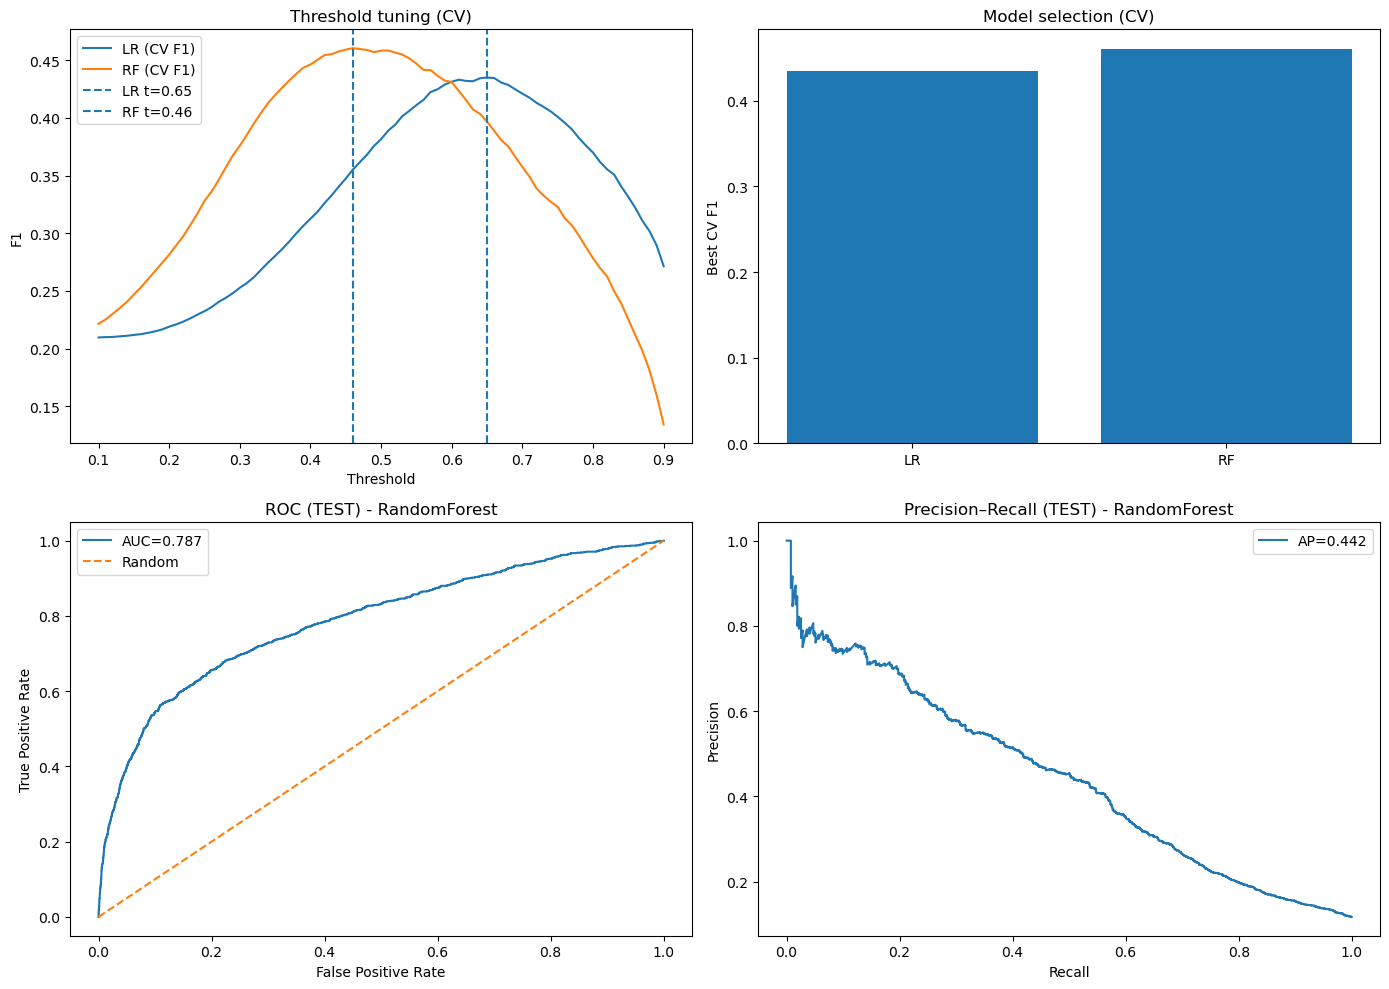

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# F1 vs threshold (CV)
axes[0, 0].plot(thresholds, lr_f1s, label="LR (CV F1)")
axes[0, 0].plot(thresholds, rf_f1s, label="RF (CV F1)")
axes[0, 0].axvline(best_lr_threshold, linestyle="--", label=f"LR t={best_lr_threshold:.2f}")
axes[0, 0].axvline(best_rf_threshold, linestyle="--", label=f"RF t={best_rf_threshold:.2f}")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("F1")
axes[0, 0].set_title("Threshold tuning (CV)")
axes[0, 0].legend()

# Best CV F1 bar
axes[0, 1].bar(["LR", "RF"], [np.max(lr_f1s), np.max(rf_f1s)])
axes[0, 1].set_ylabel("Best CV F1")
axes[0, 1].set_title("Model selection (CV)")

# ROC on test
test_proba = final_model.predict_proba(X_duration_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test_cls, test_proba)
roc_auc = auc(fpr, tpr)

axes[1, 0].plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", label="Random")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].set_title(f"ROC (TEST) - {selected_name}")
axes[1, 0].legend()

# Precision–Recall on test
prec, rec, _ = precision_recall_curve(y_test_cls, test_proba)
ap = average_precision_score(y_test_cls, test_proba)

axes[1, 1].plot(rec, prec, label=f"AP={ap:.3f}")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].set_title(f"Precision–Recall (TEST) - {selected_name}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()


# References

- Dong, X., Yu, Z., Cao, W., Shi, Y. and Ma, Q. (2020). A survey on ensemble learning. Frontiers of Computer Science, 14, pp.241-258.

- He, H. and Garcia, E.A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), pp.1263-1284.

- Hutter, F., Kotthoff, L. and Vanschoren, J. (2019). Automated Machine Learning: Methods, Systems, Challenges. Springer Nature.

- Park, J. (2022). Bank marketing dataset – EDA. Kaggle.
https://www.kaggle.com/code/jintaepark95/bank-marketing-dataset-eda

- Bellman, R. (1961). Adaptive control processes: A guided tour. Princeton University Press.

- Beyer, K., Goldstein, J., Ramakrishnan, R. and Shaft, U. (1999). When is “nearest neighbor” meaningful? In: Proceedings of the 7th International Conference on Database Theory (ICDT’99). Springer, pp. 217–235.

- Hubert, L. and Arabie, P. (1985).
Comparing partitions. Journal of Classification, 2(1), pp.193–218.

- Breiman, L. (2001).
Random forests. Machine Learning, 45(1), pp.5–32.

- Hastie, T., Tibshirani, R. and Friedman, J. (2009).
The Elements of Statistical Learning (2nd ed.). Springer.

- Kuhn, M. and Johnson, K. (2013).
Applied Predictive Modeling. Springer.

- Kuncheva, L.I. and Whitaker, C.J. (2003).
Measures of diversity in classifier ensembles and their relationship with the ensemble accuracy. Machine Learning, 51(2), pp.181–207.

- Breiman, L. (1996).
Bagging predictors. Machine Learning, 24(2), pp.123–140.

- Wolpert, D.H. (1992).
Stacked generalization. Neural Networks, 5(2), pp.241–259.
